In [12]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv').drop_duplicates()

In [5]:
df.head()

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,independent,15.50,sector 43,28233.0,5490.00,Plot area 610(510.04 sq.m.),5,6,3,3.0,East,Moderately Old,house,NaN,5490.0,NaN,1,1,1,1,0,0,76
1,trisara our homes 3,0.38,sohna road,6312.0,602.03,Built Up area: 602 (55.93 sq.m.),2,2,2,1.0,NaN,Undefined,flat,NaN,602.0,NaN,0,0,0,0,0,0,0
2,sare green parc phase 3,0.70,sector 92,5279.0,1326.01,Super Built up area 1326(123.19 sq.m.)Built Up...,3,2,2,4.0,NaN,Relatively New,flat,1326.0,1325.0,1320.00,0,0,0,0,0,0,56
3,emaar gurgaon greens,1.60,sector 102,9696.0,1650.17,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,8.0,NaN,Relatively New,flat,1650.0,NaN,1022.58,0,0,0,0,0,0,46
4,emaar mgf the palm drive,3.98,sector 66,18090.0,2200.11,Super Built up area 2200(204.39 sq.m.),3,4,3+,2.0,South-East,Moderately Old,flat,2200.0,NaN,NaN,0,1,0,0,0,2,123


In [13]:
df.shape

(3678, 23)

In [7]:
df.columns

Index(['society', 'price', 'sector', 'price_per_sqft', 'area', 'areaWithType',
       'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession',
       'property_type', 'super_built_up_area', 'built_up_area', 'carpet_area',
       'study room', 'servant room', 'store room', 'pooja room', 'others',
       'furnishing_type', 'luxury_score'],
      dtype='object')

C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_49888\2797181776.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price', ylabel='Density'>

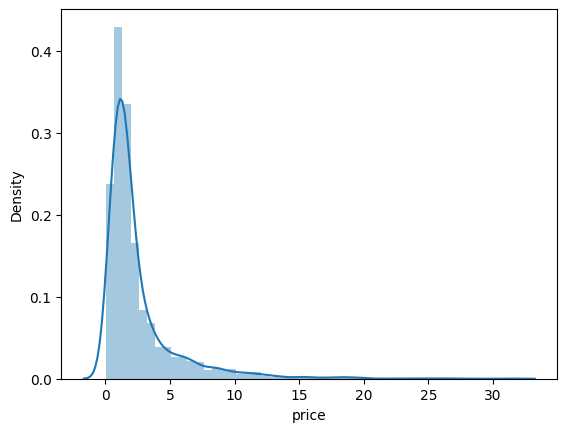

In [14]:
# outliers on the basis of price column
sns.distplot(df['price'])

<Axes: xlabel='price'>

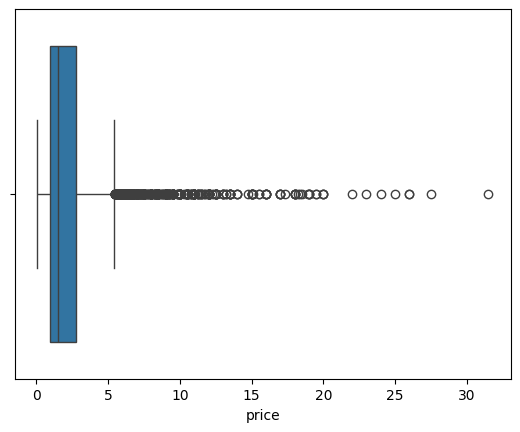

In [15]:
sns.boxplot(x=df['price'])

In [16]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(425,
 count    425.000000
 mean       9.235624
 std        4.065259
 min        5.460000
 25%        6.460000
 50%        8.000000
 75%       10.750000
 max       31.500000
 Name: price, dtype: float64)

In [17]:
outliers.sort_values('price',ascending=False).head(20)

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3651,arjun marg/ sector- 26 phase- 1/ golf course road,31.50,sector 26,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7,9,3+,3.0,North-East,Moderately Old,house,NaN,9000.0,NaN,1,1,1,1,0,1,74
2670,independent,27.50,sector 43,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,house,NaN,11286.0,NaN,1,1,0,1,1,2,42
2117,independent,26.00,sector 26,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,house,NaN,400.0,350.0,1,1,1,1,0,1,72
474,dlf city plots,26.00,sector 26,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,house,NaN,4545.0,NaN,1,1,0,1,1,2,138
990,suncity township,25.00,sector 54,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,North,Moderately Old,house,NaN,1000.0,NaN,1,1,1,1,0,0,0
3577,emaar the palm springs,24.00,sector 54,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,house,NaN,400.0,NaN,1,1,0,1,0,2,122
2505,independent,23.00,sector 26,25556.0,9000.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,South-West,Relatively New,house,NaN,9000.0,NaN,1,1,1,1,0,2,145
3739,vipul tatvam villa,22.00,sector 48,26667.0,8250.0,Plot area 1000(836.13 sq.m.),5,6,3,3.0,NaN,Moderately Old,house,NaN,1000.0,NaN,0,1,0,0,0,0,54
3049,luxury dlf city floors,20.00,sector 26,48889.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,house,NaN,500.0,NaN,0,1,0,0,0,2,31
3615,independent,20.00,sector 26,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,house,NaN,4500.0,NaN,0,1,0,1,0,1,97


In [ ]:
# on the basis of price col we can say that there are some genuine outliers but there are some data erros as well

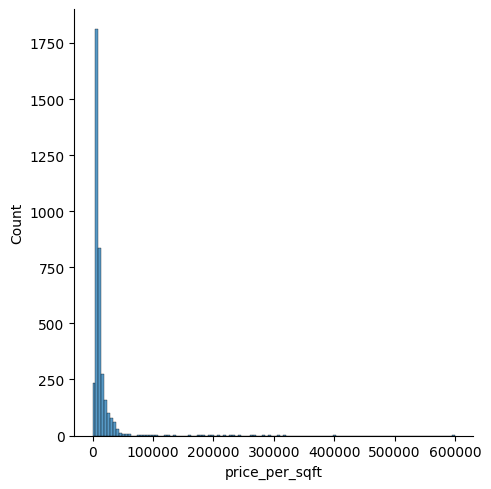

In [19]:
sns.displot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

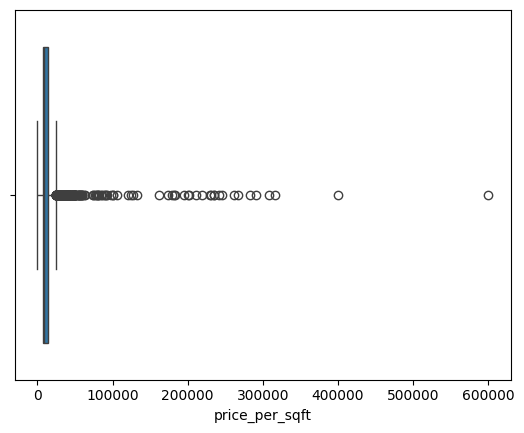

In [20]:
sns.boxplot(x=df['price_per_sqft'])

In [21]:
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(354,
 count       354.000000
 mean      52592.612994
 std       61150.458507
 min       24489.000000
 25%       28208.250000
 50%       33368.500000
 75%       41982.250000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [22]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_49888\205471443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)


In [23]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_49888\3686006548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])


In [24]:
outliers_sqft['price_per_sqft'].describe()

count      354.000000
mean     29357.836158
std      12403.074329
min       2723.000000
25%      25562.000000
50%      29870.500000
75%      35549.500000
max      82540.000000
Name: price_per_sqft, dtype: float64

In [26]:
df.update(outliers_sqft)

C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_49888\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

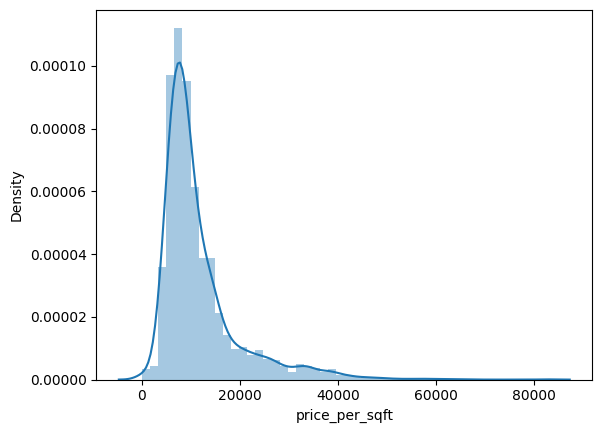

In [27]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

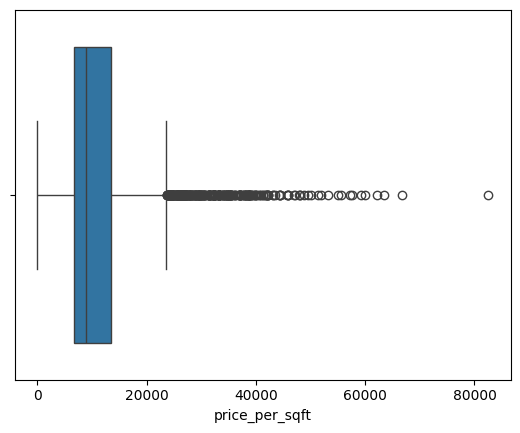

In [28]:
sns.boxplot(x=df['price_per_sqft'])

In [29]:
df[df['price_per_sqft']>50000]

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
474,dlf city plots,26.00,sector 26,57206.0,4545.00,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,house,NaN,4545.0,NaN,1,1,0,1,1,2,138
1243,emaar mgf marbella,18.00,sector 66,55556.0,3240.00,Plot area 360(301.01 sq.m.),4,4,3+,3.0,East,Moderately Old,house,NaN,3240.0,NaN,1,1,0,1,0,1,75
1304,emaar the palm springs,14.00,sector 54,62222.0,2250.00,Plot area 250(209.03 sq.m.),4,5,3+,2.0,North,Old Property,house,NaN,2250.0,NaN,1,1,0,0,0,2,160
1429,unitech vistas,9.00,sector 70,57507.0,1565.03,Built Up area: 1565 (145.39 sq.m.),3,3,0,7.0,NaN,Undefined,flat,NaN,1565.0,NaN,0,0,0,0,0,0,0
1744,nul,12.50,sector 28,51440.0,2430.00,Plot area 270(225.75 sq.m.),16,17,3+,4.0,South,Relatively New,house,NaN,2430.0,NaN,1,1,0,1,1,1,137
2069,cloudnine cottages,5.50,sohna road road,55000.0,1000.00,Plot area 1000(92.9 sq.m.),3,3,0,1.0,NaN,Moderately Old,house,NaN,1000.0,NaN,0,0,0,0,0,0,0
2117,independent,26.00,sector 26,82540.0,3150.00,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,house,NaN,400.0,350.0,1,1,1,1,0,1,72
2744,independent,14.75,sector 76,51864.0,2844.00,Plot area 316(264.22 sq.m.),16,20,3+,4.0,East,New Property,house,NaN,2844.0,NaN,1,1,1,1,0,2,153
2819,independent,16.00,sector 25,59259.0,2700.00,Plot area 350(292.64 sq.m.)Built Up area: 325 ...,16,16,3+,4.0,West,New Property,house,NaN,325.0,300.0,1,1,1,1,0,1,72
2867,malibu towne,8.50,sector 47,53125.0,1600.00,Built Up area: 1600 (148.64 sq.m.),12,12,3+,4.0,North,New Property,house,NaN,1600.0,NaN,0,0,0,0,0,2,99


In [30]:
df = df[df['price_per_sqft'] <= 50000]

<Axes: xlabel='price_per_sqft'>

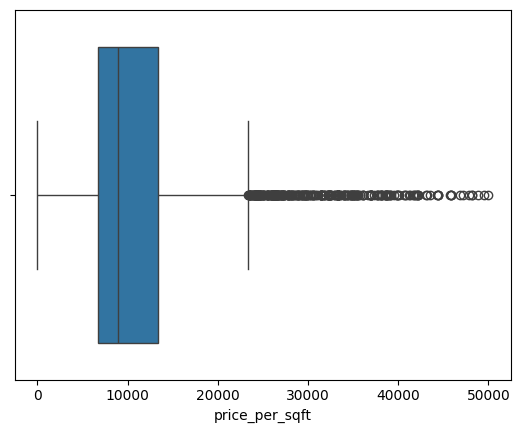

In [32]:
sns.boxplot(x=df['price_per_sqft'])

C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_49888\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

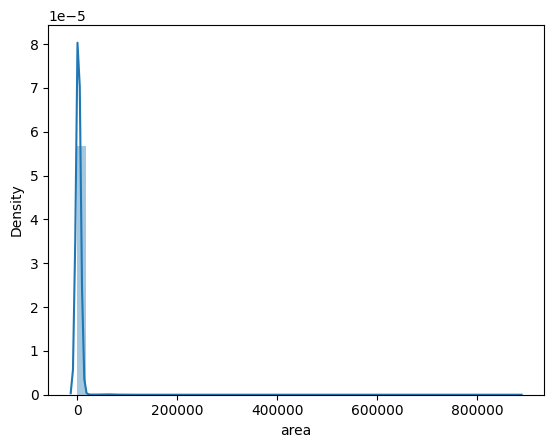

In [33]:
sns.distplot(df['area'])

In [34]:
df['area'].describe()

count      3648.000000
mean       2947.565422
std       23205.012647
min         145.000000
25%        1262.022500
50%        1750.090000
75%        2349.965000
max      875000.000000
Name: area, dtype: float64

In [35]:
df[df['area'] > 100000]

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
129,signature global solera 2,0.51,sector 107,9.0,566666.67,Carpet area: 514396 (47788.95 sq.m.),2,2,1,3.0,North,New Property,flat,NaN,NaN,514396.0,0,0,0,0,0,0,44
1875,ramsons kshitij,0.31,sector 95,5.0,620000.00,Carpet area: 607936 (56479.1 sq.m.),2,2,1,1.0,North-East,Relatively New,flat,NaN,NaN,607936.0,1,0,0,0,1,0,65
2830,signature the roselia,0.45,sector 95,7.0,642857.14,Carpet area: 569243 (52884.41 sq.m.),2,2,2,2.0,South-West,New Property,flat,NaN,NaN,569243.0,0,0,0,0,0,0,76
3252,hcbs sports ville,0.35,sohna road,4.0,875000.00,Built Up area: 737147 (68483.2 sq.m.),2,2,2,8.0,NaN,Relatively New,flat,NaN,737147.0,NaN,0,0,0,0,0,1,44
3407,independent,5.00,sector 50,232.0,215517.00,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,New Property,house,NaN,2.0,NaN,1,1,0,1,1,2,0


In [36]:
df = df[df['area'] < 100000]

C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_49888\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

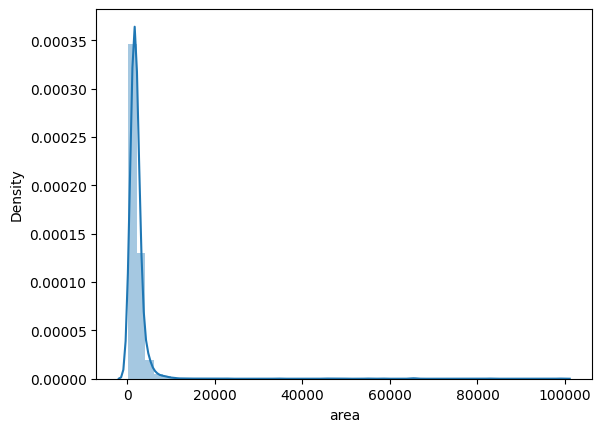

In [37]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

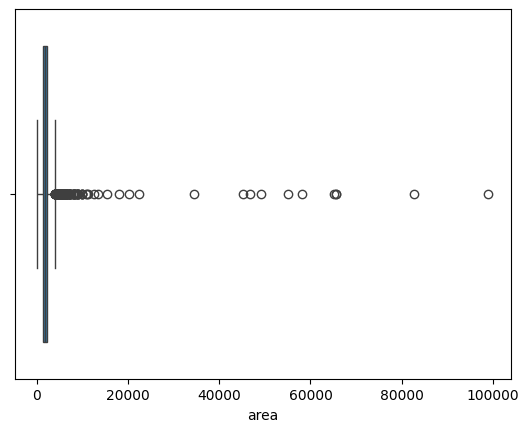

In [38]:
sns.boxplot(x=df['area'])

In [49]:
df[df['area'] > 10000].sort_values('area',ascending=False)



,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3375,ganpati heights apartment,1.25,sector 13,151.0,82781.00,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,house,NaN,115.0,NaN,0,0,0,0,1,0,7
658,dlf city plot phase 4,13.00,sector 28,1992.0,65261.00,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,house,NaN,NaN,7250.00,0,0,0,0,0,0,0
2962,independent,7.30,sector 25,1560.0,46795.00,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,house,NaN,5800.0,5200.00,0,1,1,0,0,2,109
1571,independent,6.25,sector 57,2778.0,22498.00,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,3.0,North-East,New Property,house,NaN,2660.0,2500.00,0,1,0,0,0,2,61
1913,independent,5.50,sector 43,2716.0,20250.00,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,3.0,East,Moderately Old,house,NaN,2850.0,2250.00,1,1,0,1,1,2,123
746,godrej air,2.50,sector 85,1379.0,18129.08,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Under Construction,flat,NaN,NaN,18122.00,1,0,0,1,1,2,44
758,unitech aspen greens,6.95,sector 50,4490.0,15479.00,Plot area 240(200.67 sq.m.)Built Up area: 2160...,3,3,1,2.0,North-East,Moderately Old,house,NaN,2160.0,1720.00,0,1,0,0,0,0,160
3704,godrej icon,1.75,sector 88a,1384.0,12644.51,Carpet area: 1175.11,3,3,3+,6.0,NaN,New Property,flat,NaN,NaN,1175.11,0,0,0,0,0,0,55
2670,independent,27.50,sector 43,24366.0,11286.00,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,house,NaN,11286.0,NaN,1,1,0,1,1,2,42
2151,m3m golfestate,13.20,sector 65,12000.0,11000.00,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,flat,NaN,NaN,11000.00,0,1,0,0,0,0,60


In [50]:
df[df['area'] > 10000].sort_values('area',ascending=False)


,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3375,ganpati heights apartment,1.25,sector 13,151.0,82781.00,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,house,NaN,115.0,NaN,0,0,0,0,1,0,7
658,dlf city plot phase 4,13.00,sector 28,1992.0,65261.00,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,house,NaN,NaN,7250.00,0,0,0,0,0,0,0
2962,independent,7.30,sector 25,1560.0,46795.00,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,house,NaN,5800.0,5200.00,0,1,1,0,0,2,109
1571,independent,6.25,sector 57,2778.0,22498.00,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,3.0,North-East,New Property,house,NaN,2660.0,2500.00,0,1,0,0,0,2,61
1913,independent,5.50,sector 43,2716.0,20250.00,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,3.0,East,Moderately Old,house,NaN,2850.0,2250.00,1,1,0,1,1,2,123
746,godrej air,2.50,sector 85,1379.0,18129.08,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Under Construction,flat,NaN,NaN,18122.00,1,0,0,1,1,2,44
758,unitech aspen greens,6.95,sector 50,4490.0,15479.00,Plot area 240(200.67 sq.m.)Built Up area: 2160...,3,3,1,2.0,North-East,Moderately Old,house,NaN,2160.0,1720.00,0,1,0,0,0,0,160
3704,godrej icon,1.75,sector 88a,1384.0,12644.51,Carpet area: 1175.11,3,3,3+,6.0,NaN,New Property,flat,NaN,NaN,1175.11,0,0,0,0,0,0,55
2670,independent,27.50,sector 43,24366.0,11286.00,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,house,NaN,11286.0,NaN,1,1,0,1,1,2,42
2151,m3m golfestate,13.20,sector 65,12000.0,11000.00,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,flat,NaN,NaN,11000.00,0,1,0,0,0,0,60


In [51]:
df.loc[3375,'area'] = 115*9
df.loc[658,'area'] = 7250
df.loc[2962,'area'] = 5800
df.loc[1571,'area'] = 2660
df.loc[1913,'area'] = 2850
df.loc[746,'area'] = 1812
df.loc[758,'area'] = 2160
df.loc[3704,'area'] = 1175

C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_49888\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

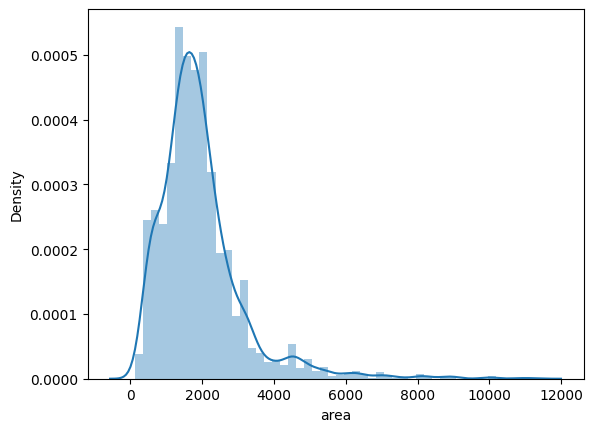

In [52]:
sns.distplot(df['area'])

In [53]:
df['area'].describe()

count     3633.000000
mean      1949.941594
std       1215.297468
min        145.000000
25%       1260.050000
50%       1747.040000
75%       2325.010000
max      11286.000000
Name: area, dtype: float64

C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_49888\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

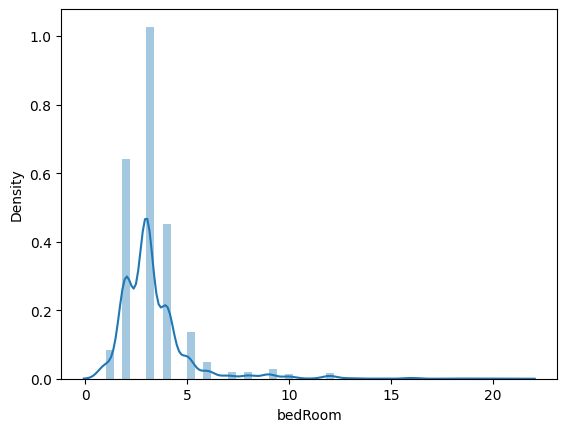

In [54]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

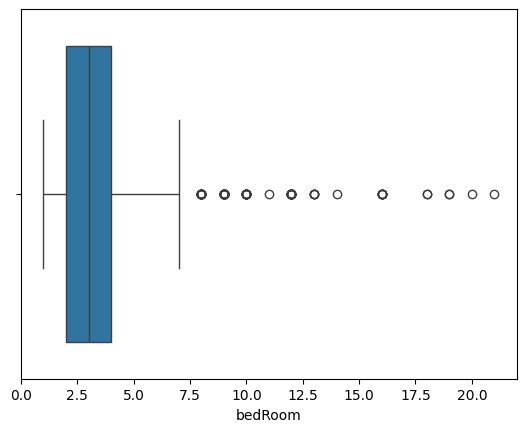

In [55]:
sns.boxplot(x=df['bedRoom'])

In [56]:
df['bedRoom'].describe()

count    3633.000000
mean        3.333058
std         1.829834
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        21.000000
Name: bedRoom, dtype: float64

In [57]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2999,independent,5.00,sector 54,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,5.0,North,Relatively New,house,NaN,1161.0,NaN,0,1,0,0,0,1,49
138,independent,4.50,sector 43,39062.0,1152.0,Plot area 128(107.02 sq.m.),20,20,3+,4.0,East,Relatively New,house,NaN,1152.0,NaN,0,1,0,0,0,1,22
1189,independent,3.93,sector 17a,24214.0,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,4.0,North-West,Relatively New,house,NaN,1622.0,NaN,1,1,1,1,0,0,74
3031,independent,3.87,sector 17a,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,5.0,North-West,Relatively New,house,NaN,7500.0,NaN,1,0,1,0,0,0,68
2373,independent,5.50,sector 54,38194.0,1440.0,Plot area 160(133.78 sq.m.),18,18,3+,4.0,South-West,Relatively New,house,NaN,1440.0,NaN,0,1,0,0,0,1,70
3002,private house,7.05,sector 55,46906.0,1503.0,Plot area 167(139.63 sq.m.),18,18,3+,4.0,North-East,Relatively New,house,NaN,1503.0,NaN,0,0,0,0,1,1,57
977,independent,4.50,sector 11,25000.0,1800.0,Plot area 200(167.23 sq.m.),16,16,3+,4.0,South,Relatively New,house,NaN,1800.0,NaN,0,0,0,0,0,2,20
2684,independent,12.00,sector 40,38986.0,3078.0,Plot area 342(285.96 sq.m.),16,16,3+,4.0,NaN,New Property,house,NaN,3078.0,NaN,1,1,1,1,0,2,0
2403,independent,12.39,sector 56,45889.0,2700.0,Plot area 300(250.84 sq.m.),16,18,3+,4.0,North-East,New Property,house,NaN,2700.0,NaN,0,1,0,1,0,2,49
3049,luxury dlf city floors,20.00,sector 26,48888.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,house,NaN,500.0,NaN,0,1,0,0,0,2,31


In [58]:
df = df[df['bedRoom'] <= 10]

C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_49888\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

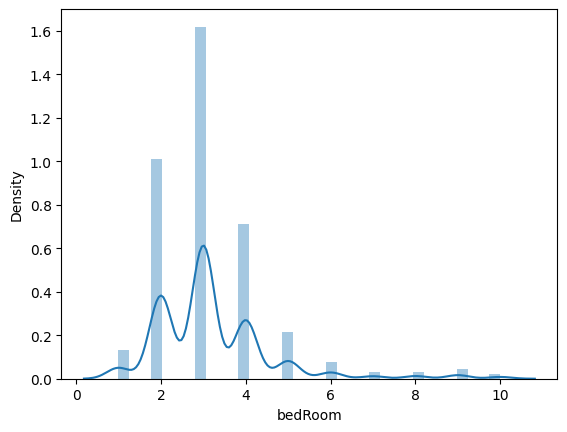

In [59]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

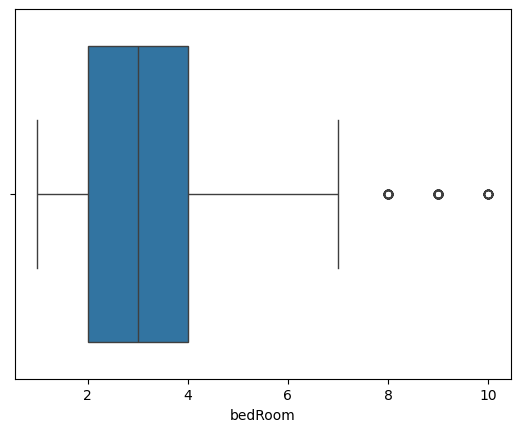

In [62]:
sns.boxplot(x =df['bedRoom'])


In [63]:
df['bedRoom'].describe()

count    3588.000000
mean        3.203177
std         1.393650
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: bedRoom, dtype: float64

C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_49888\2904465235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


<Axes: xlabel='bathroom', ylabel='Density'>

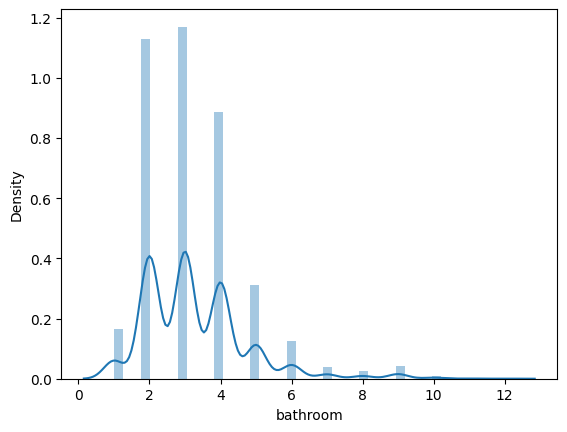

In [64]:
sns.distplot(df['bathroom'])

<Axes: xlabel='bathroom'>

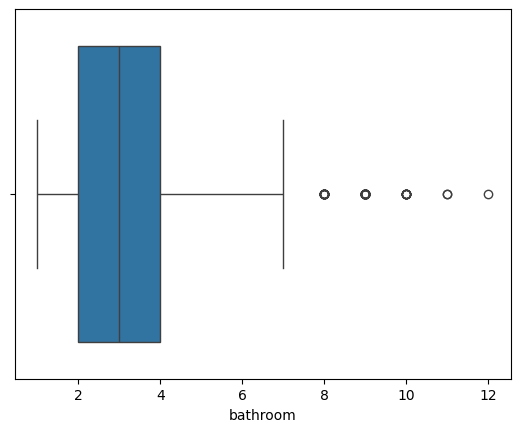

In [65]:
sns.boxplot(x=df['bathroom'])

In [66]:
df[df['bathroom'] > 10].sort_values('bathroom',ascending=False)

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2832,adani brahma samsara,18.02,sector 60,28200.0,6390.0,Built Up area: 6390 (593.65 sq.m.),9,12,3+,3.0,North-East,Relatively New,house,NaN,6390.0,NaN,0,1,0,0,0,2,146
1840,independent,7.00,sector 39,10000.0,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3+,4.0,South-East,Relatively New,house,NaN,7000.0,NaN,0,0,0,1,0,1,38
2678,independent,11.00,sector 24,28902.0,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8,11,3+,3.0,East,Old Property,house,NaN,5000.0,NaN,1,1,0,1,1,2,39


In [67]:
df.head()

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,independent,15.50,sector 43,28233.0,5490.00,Plot area 610(510.04 sq.m.),5,6,3,3.0,East,Moderately Old,house,NaN,5490.0,NaN,1,1,1,1,0,0,76
1,trisara our homes 3,0.38,sohna road,6312.0,602.03,Built Up area: 602 (55.93 sq.m.),2,2,2,1.0,NaN,Undefined,flat,NaN,602.0,NaN,0,0,0,0,0,0,0
2,sare green parc phase 3,0.70,sector 92,5279.0,1326.01,Super Built up area 1326(123.19 sq.m.)Built Up...,3,2,2,4.0,NaN,Relatively New,flat,1326.0,1325.0,1320.00,0,0,0,0,0,0,56
3,emaar gurgaon greens,1.60,sector 102,9696.0,1650.17,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,8.0,NaN,Relatively New,flat,1650.0,NaN,1022.58,0,0,0,0,0,0,46
4,emaar mgf the palm drive,3.98,sector 66,18090.0,2200.11,Super Built up area 2200(204.39 sq.m.),3,4,3+,2.0,South-East,Moderately Old,flat,2200.0,NaN,NaN,0,1,0,0,0,2,123


C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_49888\4184943455.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])


<Axes: xlabel='super_built_up_area', ylabel='Density'>

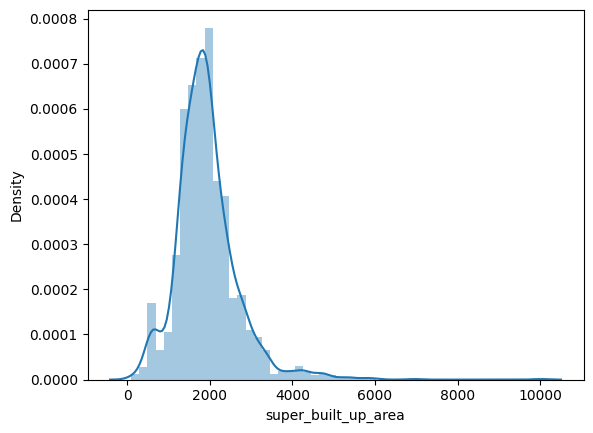

In [68]:
sns.distplot(df['super_built_up_area'])

<Axes: xlabel='super_built_up_area'>

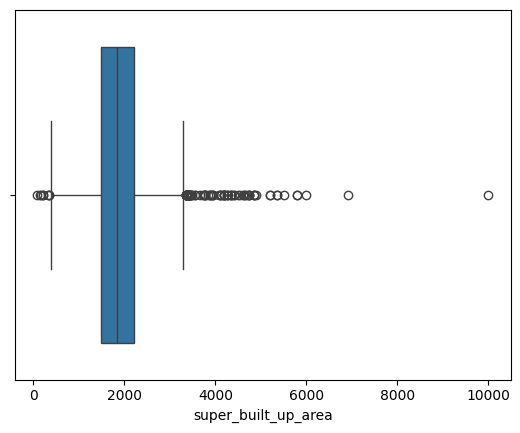

In [69]:
sns.boxplot(x=df['super_built_up_area'])

In [70]:
df['super_built_up_area'].describe()

count     1875.000000
mean      1924.328827
std        762.858335
min         89.000000
25%       1479.500000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [71]:
df[df['super_built_up_area'] > 6000]

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3182,krrish provence estate,7.5,gwal pahari,7500.0,10000.00,Super Built up area 10000(929.03 sq.m.),5,6,3+,23.0,North-East,Relatively New,flat,10000.0,NaN,NaN,0,1,0,1,1,0,49
3266,bestech park view grand spa,4.7,sector 81,6786.0,6926.02,Super Built up area 6926(643.45 sq.m.),4,4,3+,19.0,North,Relatively New,flat,6926.0,NaN,NaN,0,1,0,0,0,2,140


C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_49888\3494228458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

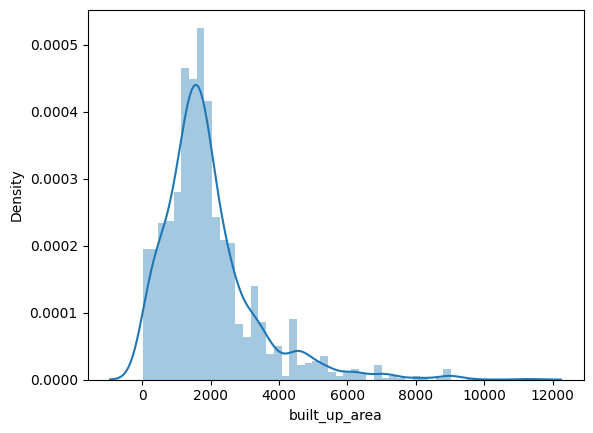

In [72]:
sns.distplot(df['built_up_area'])

<Axes: xlabel='built_up_area'>

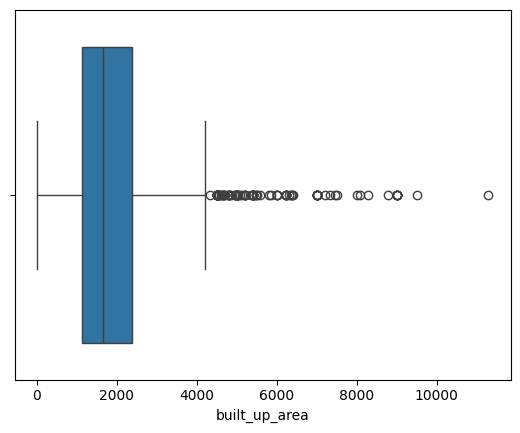

In [73]:
sns.boxplot(x=df['built_up_area'])

In [74]:
df[df['built_up_area'] > 10000]

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2670,independent,27.5,sector 43,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,house,NaN,11286.0,NaN,1,1,0,1,1,2,42


C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_49888\3905767603.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


<Axes: xlabel='carpet_area', ylabel='Density'>

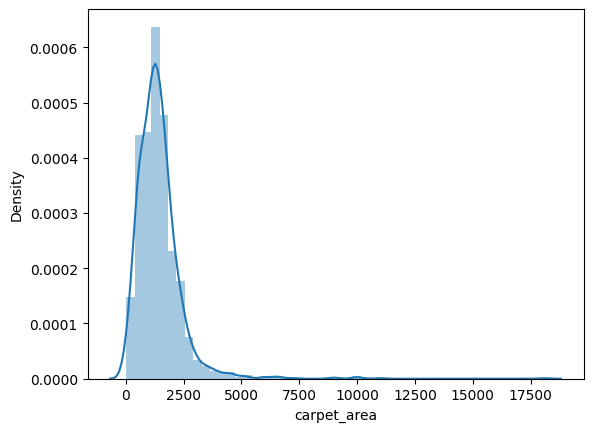

In [75]:
sns.distplot(df['carpet_area'])

<Axes: xlabel='carpet_area'>

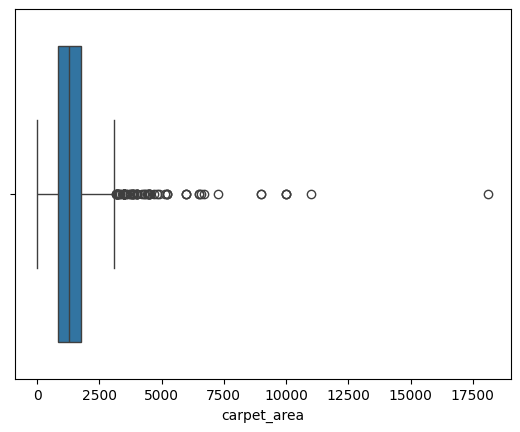

In [76]:
sns.boxplot(x=df['carpet_area'])

In [77]:
df[df['carpet_area'] > 10000]

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
746,godrej air,2.5,sector 85,1379.0,1812.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Under Construction,flat,NaN,NaN,18122.0,1,0,0,1,1,2,44
2151,m3m golfestate,13.2,sector 65,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,flat,NaN,NaN,11000.0,0,1,0,0,0,0,60


In [78]:
df.loc[746,'carpet_area'] = 1812

In [79]:
df[df['carpet_area'] > 10000]

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2151,m3m golfestate,13.2,sector 65,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,flat,NaN,NaN,11000.0,0,1,0,0,0,0,60


In [80]:
df.head()

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,independent,15.50,sector 43,28233.0,5490.00,Plot area 610(510.04 sq.m.),5,6,3,3.0,East,Moderately Old,house,NaN,5490.0,NaN,1,1,1,1,0,0,76
1,trisara our homes 3,0.38,sohna road,6312.0,602.03,Built Up area: 602 (55.93 sq.m.),2,2,2,1.0,NaN,Undefined,flat,NaN,602.0,NaN,0,0,0,0,0,0,0
2,sare green parc phase 3,0.70,sector 92,5279.0,1326.01,Super Built up area 1326(123.19 sq.m.)Built Up...,3,2,2,4.0,NaN,Relatively New,flat,1326.0,1325.0,1320.00,0,0,0,0,0,0,56
3,emaar gurgaon greens,1.60,sector 102,9696.0,1650.17,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,8.0,NaN,Relatively New,flat,1650.0,NaN,1022.58,0,0,0,0,0,0,46
4,emaar mgf the palm drive,3.98,sector 66,18090.0,2200.11,Super Built up area 2200(204.39 sq.m.),3,4,3+,2.0,South-East,Moderately Old,flat,2200.0,NaN,NaN,0,1,0,0,0,2,123


C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_49888\3385064764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])


<Axes: xlabel='luxury_score', ylabel='Density'>

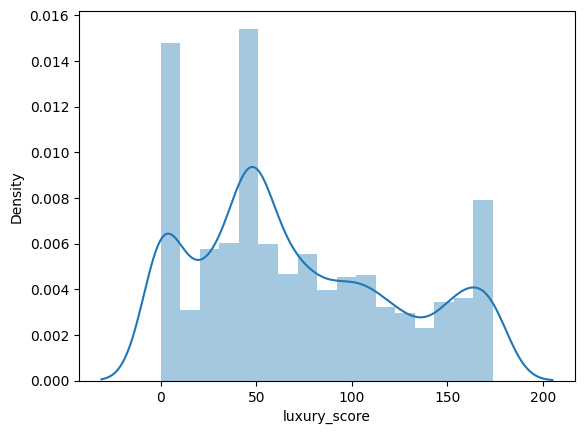

In [81]:
sns.distplot(df['luxury_score'])

<Axes: ylabel='luxury_score'>

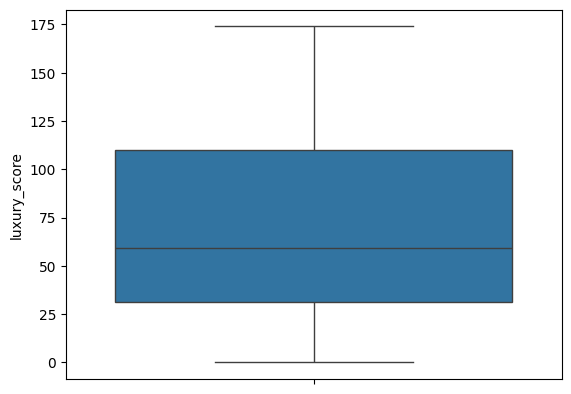

In [82]:
sns.boxplot(df['luxury_score'])

In [83]:
df.shape

(3588, 23)

In [84]:
df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_49888\3958460563.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price_per_sqft'] = round((df['price']*10000000)/df['area'])


In [85]:
df.head()

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,independent,15.50,sector 43,28233.0,5490.00,Plot area 610(510.04 sq.m.),5,6,3,3.0,East,Moderately Old,house,NaN,5490.0,NaN,1,1,1,1,0,0,76
1,trisara our homes 3,0.38,sohna road,6312.0,602.03,Built Up area: 602 (55.93 sq.m.),2,2,2,1.0,NaN,Undefined,flat,NaN,602.0,NaN,0,0,0,0,0,0,0
2,sare green parc phase 3,0.70,sector 92,5279.0,1326.01,Super Built up area 1326(123.19 sq.m.)Built Up...,3,2,2,4.0,NaN,Relatively New,flat,1326.0,1325.0,1320.00,0,0,0,0,0,0,56
3,emaar gurgaon greens,1.60,sector 102,9696.0,1650.17,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,8.0,NaN,Relatively New,flat,1650.0,NaN,1022.58,0,0,0,0,0,0,46
4,emaar mgf the palm drive,3.98,sector 66,18090.0,2200.11,Super Built up area 2200(204.39 sq.m.),3,4,3+,2.0,South-East,Moderately Old,flat,2200.0,NaN,NaN,0,1,0,0,0,2,123


C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_49888\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

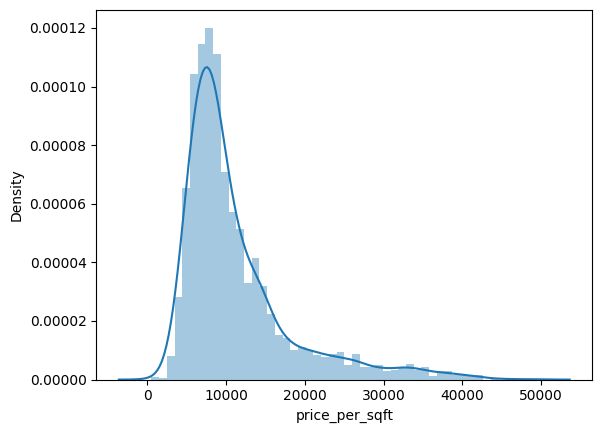

In [86]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

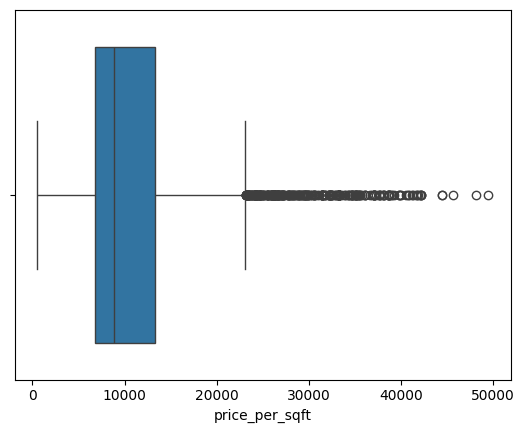

In [88]:
sns.boxplot(x = df['price_per_sqft'])

In [89]:
df[df['price_per_sqft'] > 42000]

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
103,independent,5.0,sector 55,44444.0,1125.0,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9,9,3+,5.0,East,New Property,house,NaN,115.0,100.0,0,0,0,0,1,2,44
212,independent,12.0,sector 28,42194.0,2844.0,Plot area 316(264.22 sq.m.),4,5,3+,4.0,East,Relatively New,house,NaN,2844.0,NaN,0,1,1,1,0,2,60
607,independent,19.0,sector 26,42222.0,4500.0,Plot area 500(418.06 sq.m.),6,8,3+,3.0,East,Moderately Old,house,NaN,4500.0,NaN,1,1,1,1,0,2,103
795,independent,9.9,sector 105,49500.0,2000.0,Built Up area: 2000 (185.81 sq.m.)Carpet area:...,2,2,2,3.0,North,Undefined,house,NaN,2000.0,1800.0,0,0,0,0,0,0,0
1640,sushant lok 1 builder floors,13.0,sector 43,48148.0,2700.0,Plot area 300(250.84 sq.m.),3,3,3+,4.0,North,New Property,house,NaN,2700.0,NaN,0,0,0,1,0,2,7
1976,dlf city plots,19.0,sector 26,42054.0,4518.0,Plot area 502(419.74 sq.m.),6,6,3,2.0,East,Relatively New,house,NaN,4518.0,NaN,1,1,0,0,0,2,121
2035,independent,13.0,sector 25,45710.0,2844.0,Plot area 316(264.22 sq.m.),6,8,3+,NaN,NaN,Relatively New,house,NaN,2844.0,NaN,1,1,1,1,0,1,0
2169,independent,9.5,sector 43,42222.0,2250.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,5,5,3+,2.0,North-East,Relatively New,house,NaN,300.0,250.0,0,1,0,1,0,2,88
3615,independent,20.0,sector 26,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,house,NaN,4500.0,NaN,0,1,0,1,0,1,97


In [91]:
x = df[df['price_per_sqft'] <= 20000]
(x['area']/x['bedRoom']).quantile(0.05)

np.float64(250.525)

In [92]:
df[df['area']/df['bedRoom']<250]

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
9,not applicable,0.75,sector 4,11719.0,640.00,Plot area 640(59.46 sq.m.),5,4,3,2.0,NaN,Moderately Old,house,NaN,640.0,NaN,0,0,0,0,0,0,0
12,independent,1.16,sector 7,11694.0,992.00,Plot area 992(92.16 sq.m.)Carpet area: 992 sq....,5,4,2,3.0,North-East,Moderately Old,house,NaN,NaN,992.0,0,0,0,0,1,0,39
27,laxmi pareena,0.30,sector 99a,6666.0,450.05,Carpet area: 450 (41.81 sq.m.),2,1,0,12.0,North,Undefined,flat,NaN,NaN,450.0,0,0,0,0,0,0,0
70,signature global solera,0.28,sector 107,5828.0,480.44,Carpet area: 489 (45.43 sq.m.),2,2,2,0.0,North-East,Relatively New,flat,NaN,NaN,489.0,0,0,0,0,0,0,45
76,zara aavaas,0.49,sector 104,6577.0,745.02,Super Built up area 745(69.21 sq.m.)Carpet are...,3,2,2,7.0,NaN,Under Construction,flat,745.0,NaN,645.0,0,0,0,0,0,0,74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3752,independent,1.50,sector 13,11538.0,1300.00,Plot area 1300(120.77 sq.m.),10,7,3,4.0,East,Moderately Old,house,NaN,1300.0,NaN,0,0,0,0,0,0,0
3757,dlf city plots phase 2,6.50,sector 25,33592.0,1935.00,Plot area 215(179.77 sq.m.),9,9,3+,3.0,West,Old Property,house,NaN,1935.0,NaN,1,1,1,1,0,2,142
3760,supertech basera,0.36,sector 79,7643.0,471.02,Built Up area: 546 (50.73 sq.m.)Carpet area: 4...,2,2,1,4.0,NaN,New Property,flat,NaN,546.0,471.0,0,0,0,0,0,0,60
3770,independent,0.42,sector 9,9333.0,450.00,Built Up area: 450 (41.81 sq.m.),5,3,2,2.0,NaN,Undefined,house,NaN,450.0,NaN,0,0,0,0,0,0,0


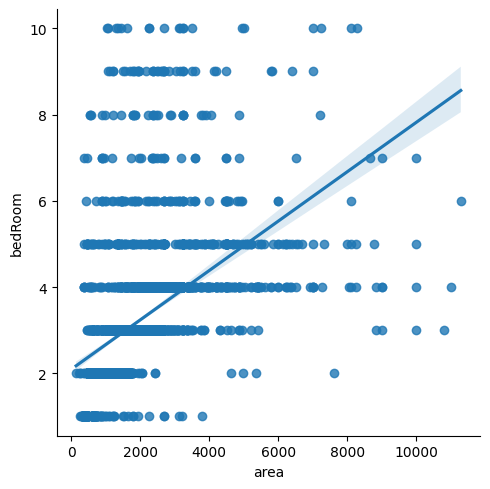

In [93]:
sns.lmplot(data = df, x = 'area', y = 'bedRoom')

In [94]:
df['area_room_ratio'] = df['area']/ df['bedRoom']

C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_49888\2979360121.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['area_room_ratio'] = df['area']/ df['bedRoom']


In [95]:
df[df['area_room_ratio']<250]['bedRoom'].value_counts()

bedRoom
2     47
3     33
5     28
4     17
6     17
9     15
8     12
10     8
7      8
Name: count, dtype: int64

In [96]:
df = df[df['area_room_ratio']>100]

In [99]:
outlier_df = df[(df['area_room_ratio'] < 250) & (df['bedRoom'] > 3)]

In [100]:
outlier_df['bedRoom'] = round(outlier_df['bedRoom'] / outlier_df['floorNum'])

C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_49888\1158418728.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outlier_df['bedRoom'] = round(outlier_df['bedRoom'] / outlier_df['floorNum'])


In [103]:
df.update(outlier_df)

In [104]:
df['area_room_ratio'] = df['area']/ df['bedRoom']

In [105]:
df[(df['area_room_ratio'] < 250) & (df['bedRoom'] > 4)]

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
619,shivpuri,2.80,sector 7,12444.0,2250.0,Plot area 2250(209.03 sq.m.),10,7,3,1.0,NaN,Old Property,house,NaN,2250.0,NaN,1,1,0,1,1,2,0,225.000000
757,"bhim nagar, sector 6",0.85,sector 6,14096.0,603.0,Plot area 67(6.22 sq.m.),5,2,2,1.0,NaN,Old Property,house,NaN,67.0,NaN,0,0,0,1,0,0,29,120.600000
906,independent,3.50,sector 11,15556.0,2250.0,Built Up area: 2250 (209.03 sq.m.),10,1,0,1.0,NaN,New Property,house,NaN,2250.0,NaN,0,0,0,0,0,0,0,225.000000
1296,independent,1.10,sector 105,12222.0,900.0,Carpet area: 900 (83.61 sq.m.),6,4,1,1.0,South-West,Undefined,house,NaN,NaN,900.0,0,0,0,0,0,0,0,150.000000
1381,independent,2.50,sector 12,13889.0,1800.0,Plot area 1800(167.23 sq.m.),9,5,2,1.0,South-East,Old Property,house,NaN,1800.0,NaN,0,0,0,1,0,0,8,200.000000
1928,independent,0.85,sector 3 phase 2,9444.0,900.0,Carpet area: 900 (83.61 sq.m.),5,3,3,1.0,NaN,Undefined,house,NaN,NaN,900.0,0,0,0,0,0,0,0,180.000000
2150,independent,1.16,sector 7,11717.0,990.0,Carpet area: 110 (91.97 sq.m.),5,4,2,1.0,North-East,Undefined,house,NaN,NaN,110.0,0,0,0,0,0,0,0,198.000000
2558,independent,0.32,sector 17,5664.0,565.0,Built Up area: 565 (52.49 sq.m.),5,1,0,1.0,NaN,Undefined,house,NaN,565.0,NaN,0,0,0,0,0,0,0,113.000000
2806,independent,0.80,manesar,6667.0,1200.0,Plot area 1200(111.48 sq.m.),8,8,2,1.0,NaN,Relatively New,house,NaN,1200.0,NaN,0,0,0,0,0,0,0,150.000000
3255,independent,1.10,sector 3 phase 2,10000.0,1100.0,Built Up area: 1100 (102.19 sq.m.)Carpet area:...,5,4,2,1.0,East,Undefined,house,NaN,1100.0,900.0,0,0,0,0,0,0,0,220.000000


In [112]:
df = df[~((df['area_room_ratio'] < 250) & (df['bedRoom'] > 4))]

In [113]:
df.shape

(3555, 24)

In [114]:
df.to_csv('gurgaon_properties_outliers_treated.csv', index = False)